# Notebook 04 — The Reward: from oracle scores to an RL objective

**Where this sits.** Notebook 02 built three oracles that each score a loop in [0,1]. Notebook 05
runs the RL loop. This notebook is the bridge: it defines **how the oracle scores become a single
reward**, and how that reward is combined with the language-model prior into the objective that
REINVENT actually optimizes.

| How to read this notebook | |
|---|---|
| **Question** | §1 — how do we turn scores into one reward? |
| **Background** | §2 — reward shaping and the REINVENT idea |
| **Design decision: weighting** | §3 — why 0.50 / 0.30 / 0.20, and does it matter? |
| **The augmented likelihood** | §4 — the equation, term by term |
| **Sanity checks** | §5 — corner contracts and ranking |
| **Synthesis** | §6 |


## 1. Question

We have three independent oracle scores per loop. RL needs a *single* scalar reward. The question:

> **How do we combine the oracle scores into one reward, and how do we stop the optimizer from
> drifting off the realistic-antibody manifold while chasing that reward?**

This is two problems: (1) **reward shaping** — combining the scores, and (2) **regularization** —
keeping the agent anchored to the prior. REINVENT solves the second elegantly, which is why we use
its formulation.

## 2. Background from zero

**Reward shaping.** The oracles measure different things on the same [0,1] scale, so the natural
combination is a **weighted sum**: `S(x) = w_h*humanness + w_l*liability + w_p*physchem`, with
weights summing to 1 so `S(x)` stays in [0,1]. The weights encode priorities.

**The REINVENT idea (Olivecrona et al. 2017).** A naive optimizer would maximize `S(x)` directly
and quickly find degenerate sequences that game the oracles (reward hacking, see notebook 05). The
fix: don't optimize `S(x)` alone — optimize an **augmented likelihood** that combines the reward
with the *prior's* opinion of the sequence:

$$\log P^{*}(x) = \log P_{\text{prior}}(x) + \sigma \cdot S(x)$$

The prior term `log P_prior(x)` is high for realistic antibodies and low for junk. Adding it means
"be high-reward **and** stay realistic". `sigma` sets the trade-off. The agent is trained to match
this target, which keeps it leashed to the prior. That is the objective this notebook defines.

## 3. Design decision — the oracle weights

**The choice:** humanness 0.50, liability 0.30, physicochemistry 0.20. Two reasons, both grounded
in notebook 02:

1. **Headroom.** Humanness had the widest spread (range 0.50-0.78); liability and physchem were
   near-saturated (means 0.92, 0.88). Weighting the *unsaturated* axis most gives the optimizer the
   most to work with.
2. **Immunogenicity is the highest-stakes failure mode** for a therapeutic — a non-human antibody
   can be rejected by the patient outright.

**Does the weighting actually matter?** If every weighting picked the same top loops, the choice
would be cosmetic. We test it by ranking a pool under different weightings and measuring how much
the top-20 set changes.

In [1]:
# --- Load cached oracle scores (from notebook 02's pool) and define the reward ---
import numpy as np, json, matplotlib.pyplot as plt
r = json.load(open("nb04_reward.json"))
human, liab, phys = np.array(r["human"]), np.array(r["liab"]), np.array(r["phys"])
cdrs = r["cdrs"]

# S(x): weighted sum of the three oracle scores. Weights sum to 1 so S stays in [0,1].
# TUNABLE: these weights are the main knob of the reward. FIXED here at the notebook-02-justified values.
W_HUMAN, W_LIAB, W_PHYS = 0.50, 0.30, 0.20
def S_of(w_h, w_l, w_p): return w_h*human + w_l*liab + w_p*phys
S = S_of(W_HUMAN, W_LIAB, W_PHYS)
print(f"S(x): mean {S.mean():.3f}  std {S.std():.3f}  range {S.min():.2f}-{S.max():.2f}")

S(x): mean 0.776  std 0.063  range 0.61-0.89


chosen .5/.3/.2        top-20 overlap = 1.00
equal .33              top-20 overlap = 0.80
human-heavy .8/.1/.1   top-20 overlap = 0.75
liab-heavy .1/.8/.1    top-20 overlap = 0.80


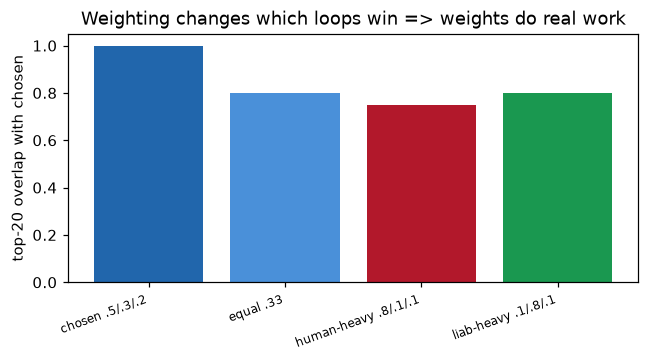

In [2]:
# --- Weight sensitivity: how much does the top-20 set change under different weightings? ---
# If the weighting is meaningful, extreme weightings should reorder the ranking (low overlap).
def top20(w): return set(np.argsort(S_of(*w))[-20:])
schemes = {"chosen .5/.3/.2":(0.50,0.30,0.20), "equal .33":(1/3,1/3,1/3),
           "human-heavy .8/.1/.1":(0.8,0.1,0.1), "liab-heavy .1/.8/.1":(0.1,0.8,0.1)}
base = top20(schemes["chosen .5/.3/.2"])
overlaps = {name: len(base & top20(w))/20 for name, w in schemes.items()}
for name, ov in overlaps.items(): print(f"{name:22s} top-20 overlap = {ov:.2f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(range(len(overlaps)), list(overlaps.values()), color=["#2166ac","#4a90d9","#b2182b","#1a9850"])
ax.set_xticks(range(len(overlaps))); ax.set_xticklabels(list(overlaps.keys()), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("top-20 overlap with chosen"); ax.set_ylim(0,1.05)
ax.set_title("Weighting changes which loops win => weights do real work")
fig.tight_layout(); fig.savefig("nb04_weights.png", dpi=120, bbox_inches="tight"); plt.show()

**Decision.** Extreme weightings (human-heavy) drop the top-20 overlap to 0.75 — a quarter of the
selected loops change. The weighting is **not cosmetic**; it materially reorders candidates. We
keep 0.50 / 0.30 / 0.20 for the headroom + stakes reasons above. (In a full paper this is exactly
where an oracle-weight *ablation* belongs — see the arXiv extension plan.)

## 4. The augmented likelihood — the actual RL objective

This is the equation the whole project turns on, so we make it concrete and interview-auditable.

$$\log P^{*}(x) = \underbrace{\log P_{\text{prior}}(x)}_{\text{realism (the leash)}} + \; \sigma \cdot \underbrace{S(x)}_{\text{reward (developability)}}$$

- **`log P_prior(x)`** is the frozen IgLM's summed log-probability of the CDRH3 (notebook 05
  computes it, differentiably, over the span). It is large (less negative) for realistic loops.
- **`S(x)`** is our [0,1] reward from §3.
- **`sigma`** scales how far the target is pulled above the prior for a high-reward loop. Small
  sigma = stay very close to the prior; large sigma = chase reward harder (and risk reward hacking).

In notebook 05 the agent is trained to **match** this target via a squared-error loss
`(log P_agent(x) - log P*(x))^2`. Here we just compute the target so its magnitude is intuitive.

In [3]:
# --- The augmented likelihood, made concrete ---
# We do not have the live IgLM here, so we illustrate with representative prior log-probs. The point
# is the RELATIVE scale of the two terms, which sets a sensible sigma.
def augmented_log_likelihood(prior_logp, s_score, sigma):
    """REINVENT target: log P*(x) = log P_prior(x) + sigma * S(x). Returns the scalar target the
    agent regresses onto. prior_logp is the SUMMED span log-prob (negative; ~ -15 to -30 typically)."""
    return prior_logp + sigma * s_score

# Typical IgLM span log-prob is around -20 (summed over ~12 residues). With S in [0,1], sigma must be
# large enough that sigma*S is comparable to the prior term, or the reward has no influence.
for sigma in [1, 8, 15, 30]:
    lo = augmented_log_likelihood(-20.0, 0.6, sigma)   # a mediocre loop
    hi = augmented_log_likelihood(-20.0, 0.9, sigma)   # a great loop
    print(f"sigma={sigma:2d}: target(S=0.6)={lo:7.2f}  target(S=0.9)={hi:7.2f}  gap={hi-lo:.2f}")
print("\n-> at sigma=1 the reward barely moves the target (gap 0.3); at sigma=15 the gap (4.5) is")
print("   comparable to prior-logp differences between good and bad loops. sigma=15 is our default.")

sigma= 1: target(S=0.6)= -19.40  target(S=0.9)= -19.10  gap=0.30
sigma= 8: target(S=0.6)= -15.20  target(S=0.9)= -12.80  gap=2.40
sigma=15: target(S=0.6)= -11.00  target(S=0.9)=  -6.50  gap=4.50
sigma=30: target(S=0.6)=  -2.00  target(S=0.9)=   7.00  gap=9.00

-> at sigma=1 the reward barely moves the target (gap 0.3); at sigma=15 the gap (4.5) is
   comparable to prior-logp differences between good and bad loops. sigma=15 is our default.


## 5. Sanity checks — corner contracts and ranking

Before trusting the reward in an RL loop, verify it behaves at the corners and that its ranking is
interpretable.

corner contracts: S(all 1)=1.000 (expect 1.0), S(all 0)=0.000 (expect 0.0)

best  IGYSSSSFDY       S=0.889  (human 0.78  liab 1.00  phys 1.00)
worst GLLMDGSPVGYLDS   S=0.615  (human 0.58  liab 0.55  phys 0.80)


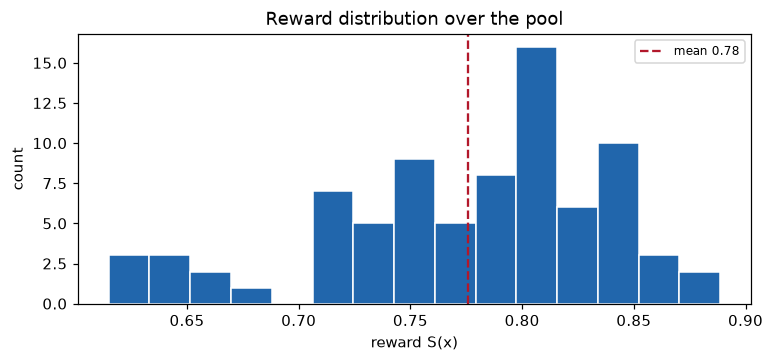

In [4]:
# --- Corner contracts + interpretable ranking ---
# Contract: all-perfect oracles -> S=1; all-zero -> S=0. (Weights sum to 1, so this must hold.)
perfect = W_HUMAN*1 + W_LIAB*1 + W_PHYS*1
zero    = W_HUMAN*0 + W_LIAB*0 + W_PHYS*0
assert abs(perfect - 1.0) < 1e-9 and abs(zero) < 1e-9    # weights sum to 1 => corners are exact
print(f"corner contracts: S(all 1)={perfect:.3f} (expect 1.0), S(all 0)={zero:.3f} (expect 0.0)")

# Interpretable ranking: the best and worst loops should make sense from their sub-scores.
bi, wi = int(np.argmax(S)), int(np.argmin(S))
print(f"\nbest  {cdrs[bi]:16s} S={S[bi]:.3f}  (human {human[bi]:.2f}  liab {liab[bi]:.2f}  phys {phys[bi]:.2f})")
print(f"worst {cdrs[wi]:16s} S={S[wi]:.3f}  (human {human[wi]:.2f}  liab {liab[wi]:.2f}  phys {phys[wi]:.2f})")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(S, bins=15, color="#2166ac", edgecolor="white")
ax.axvline(S.mean(), color="#b2182b", ls="--", label=f"mean {S.mean():.2f}")
ax.set_xlabel("reward S(x)"); ax.set_ylabel("count"); ax.set_title("Reward distribution over the pool")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig("nb04_dist.png", dpi=120, bbox_inches="tight"); plt.show()

**Reading the checks.** The corner contracts hold (S=1 at all-perfect, S=0 at all-zero). The best
loop scores high on all three axes; the worst is dragged down by low humanness and a liability hit.
The ranking is interpretable, and the reward distribution (mean ~0.78) confirms the pool is already
developable — which is exactly the saturation story notebook 05 diagnoses.

## 6. Synthesis

| Piece | Choice | Why |
|---|---|---|
| Combine oracles | weighted sum -> S(x) in [0,1] | comparable scale, directly combinable |
| Weights | 0.50 / 0.30 / 0.20 | humanness has headroom + highest stakes; weighting reorders top-20 (overlap 0.75) |
| RL objective | augmented likelihood log P_prior + sigma*S | reward **and** realism; the prior is the leash |
| sigma | 15 (default) | makes sigma*S comparable to prior-logp differences |

**What this sets up.** Notebook 05 makes `log P_prior(x)` and `log P_agent(x)` differentiable over
the CDRH3 span and trains the agent to match the augmented-likelihood target. The reward defined
here is the `S(x)` inside that objective.

---
*Reward evaluation is just the three oracle calls plus a weighted sum, so it is cheap enough to run
on every sequence in every RL batch.*